# K-mer vs Foundation Model Embeddings
Confronto MCC su 57 dataset genomici di classificazione.  
**Tesi**: i vettori di frequenza k-mer sono informativi quanto (o più) degli embedding da FM genomici pre-addestrati.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RECORDS      = '../results/classification/records.csv'
RECORDS_PCA  = '../results/classification/records_pca.csv'
RECORDS_CONCAT = '../results/concat/records_concat_best.csv'

# Nomi leggibili per i modelli FM
FM_LABELS = {
    'fm_NTv3_650M_pre_MCC':                        'NTv3-650M',
    'fm_hyenadna-medium-160k-seqlen-hf_MCC':       'HyenaDNA-160k',
    'fm_DNABERT-2-117M_MCC':                       'DNABERT-2',
}

# ── utility functions ─────────────────────────────────────────────────────────

def load_records():
    df = pd.read_csv(RECORDS, index_col=0)
    df.index.name = 'dataset'
    df['group'] = df.index.str.split('/').str[0]
    df['short'] = df.index.str.split('/').str[1]
    return df


def kmer_mcc_cols(df, include_multi=True):
    cols = [c for c in df.columns if c.startswith('kmer_k') and c.endswith('_MCC')]
    if include_multi:
        cols += [c for c in df.columns if c.startswith('kmer_multi') and c.endswith('_MCC')]
    return cols


def fm_mcc_cols(df):
    """Exclude evo2 (all-zero results)."""
    return [c for c in df.columns
            if c.startswith('fm_') and c.endswith('_MCC') and 'evo2' not in c]


def best_kmer(df):
    cols = kmer_mcc_cols(df)
    return df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1).rename('best_kmer_MCC')


def best_fm(df):
    cols = fm_mcc_cols(df)
    return df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1).rename('best_fm_MCC')


def dataset_palette(df):
    groups = sorted(df['group'].dropna().unique())
    cmap = plt.colormaps['tab20']
    return {g: cmap(i) for i, g in enumerate(groups)}


# ── load data ─────────────────────────────────────────────────────────────────
df      = load_records()
df_pca  = pd.read_csv(RECORDS_PCA, index_col=0)
df_pca  = df_pca[~df_pca.index.duplicated(keep='last')]   # rimuovi duplicato 'Promoter_B_amylolique'
df_pca['group'] = df_pca.index.str.split('/').str[0]

df_concat = pd.read_csv(RECORDS_CONCAT)
df_concat = df_concat.set_index('dataset')

palette = dataset_palette(df)

print(f"Records:  {len(df)} dataset, {len(df.columns)} colonne")
print(f"PCA:      {len(df_pca)} dataset")
print(f"Concat:   {len(df_concat)} dataset")

Records:  57 dataset, 79 colonne
PCA:      58 dataset
Concat:   57 dataset


---
## 1. Confronto per-dataset: FM embeddings vs best k-mer
Ogni punto è un dataset. **Sopra la diagonale** → FM batte il k-mer; **sotto** → k-mer vince.  
Un sottoplot per ciascun modello FM (escluso Evo2, MCC ≈ 0 su tutti i dataset).

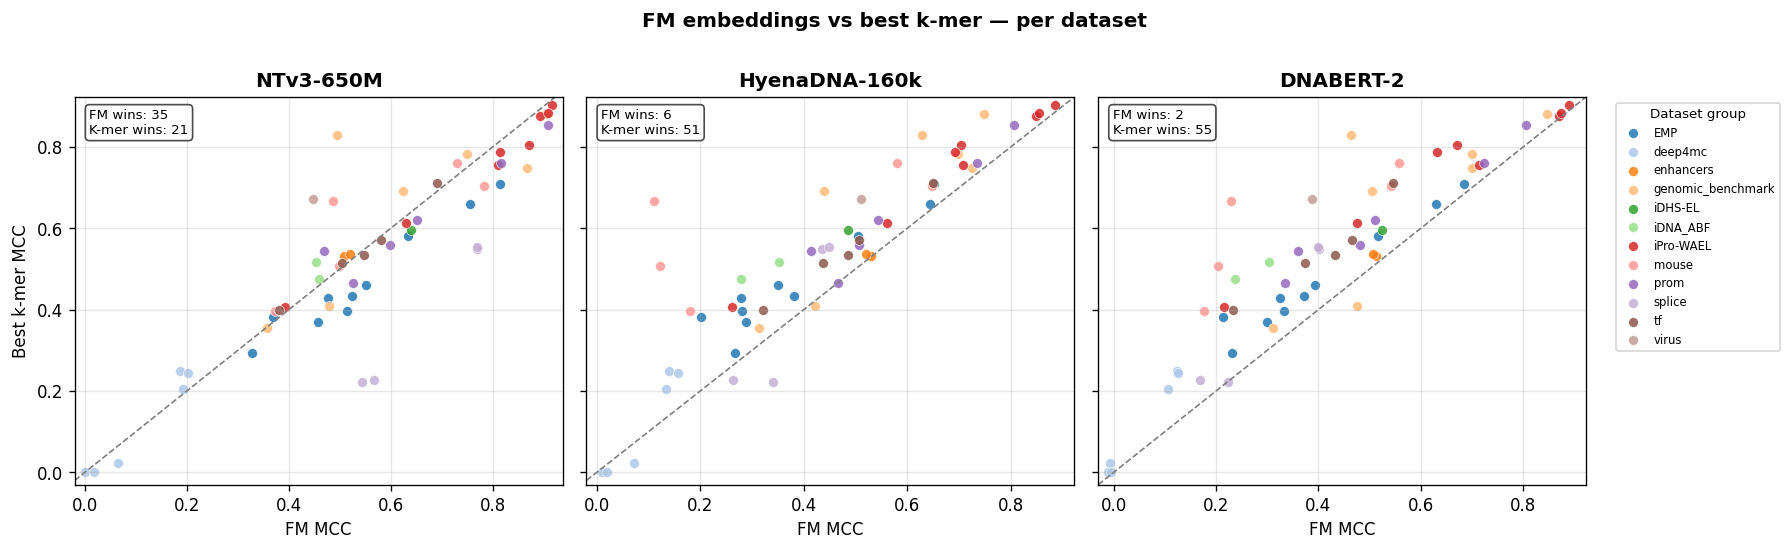

In [12]:
metric = 'MCC'
best_k = best_kmer(df)
fm_cols = list(FM_LABELS.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, col in zip(axes, fm_cols):
    x = pd.to_numeric(df[col], errors='coerce')   # FM MCC
    y = best_k                                     # best k-mer MCC

    for g, sub in df.groupby('group'):
        ax.scatter(x.loc[sub.index], y.loc[sub.index],
                   label=g, alpha=0.85, s=35, color=palette[g],
                   edgecolors='white', lw=0.4)

    lo = np.nanmin([x.min(), y.min()]) - 0.02
    hi = np.nanmax([x.max(), y.max()]) + 0.02
    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1)

    valid = pd.concat([x, y], axis=1).dropna()
    fm_wins   = (valid.iloc[:, 0] > valid.iloc[:, 1]).sum()
    kmer_wins = (valid.iloc[:, 1] > valid.iloc[:, 0]).sum()
    ax.text(0.03, 0.97, f'FM wins: {fm_wins}\nK-mer wins: {kmer_wins}',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    ax.set_title(FM_LABELS[col], fontweight='bold')
    ax.set_xlabel('FM MCC')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

axes[0].set_ylabel('Best k-mer MCC')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                title='Dataset group', fontsize=7, title_fontsize=8)
plt.suptitle('FM embeddings vs best k-mer — per dataset', y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Effetto della riduzione PCA
Confronto tra prestazioni con feature originali (asse x) e feature ridotte via PCA (asse y).  
**Sotto la diagonale** → PCA ha peggiorato; **sopra** → PCA ha aiutato.

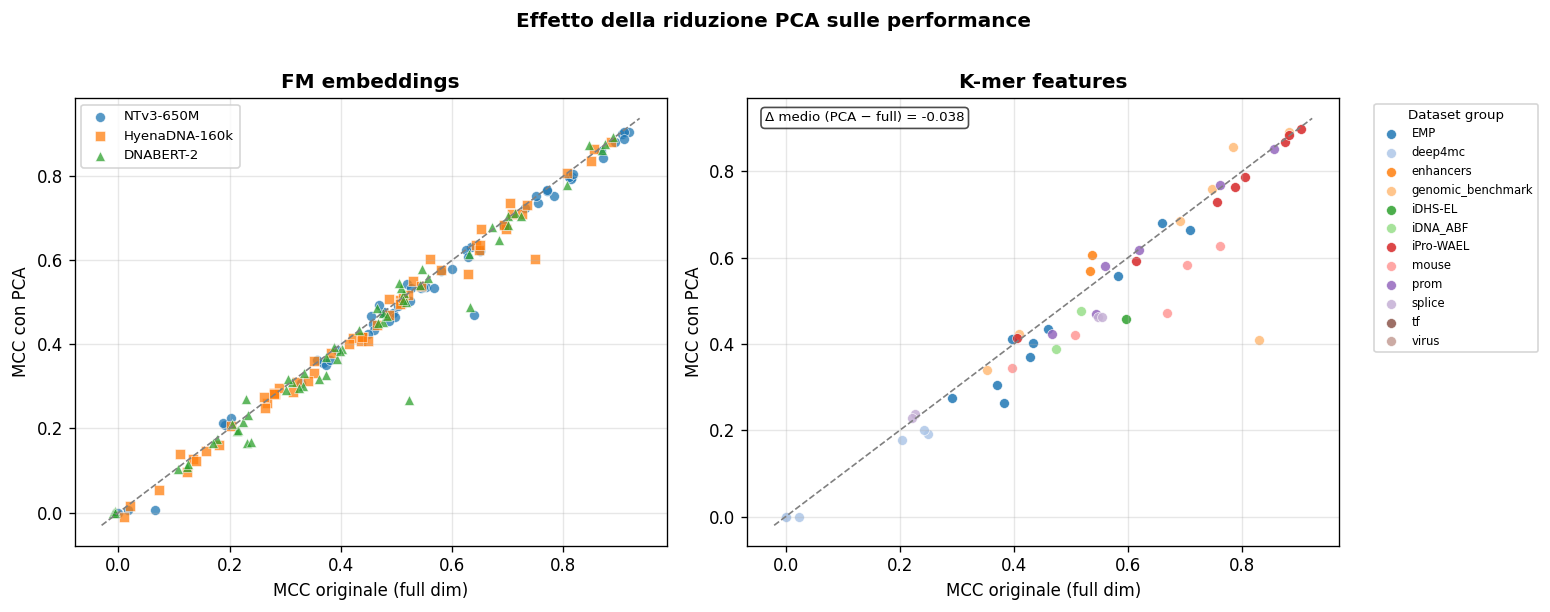

In [13]:
# Dataset comuni tra records e records_pca
common = df.index.intersection(df_pca.index)
df_c   = df.loc[common]
pca_c  = df_pca.loc[common]

# Best k-mer PCA (k=4..8) vs full (k=4,5,6,multi)
pca_kmer_cols = [c for c in pca_c.columns if c.startswith('pca_kmer_k') and c.endswith('_MCC')]
best_kmer_pca  = pca_c[pca_kmer_cols].apply(pd.to_numeric, errors='coerce').max(axis=1)
best_kmer_full = best_kmer(df_c)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── pannello sinistro: FM ──────────────────────────────────────────────────
ax = axes[0]
fm_pca_map = {
    'pca_fm_NTv3_650M_pre_MCC':                    ('NTv3-650M',   'o'),
    'pca_fm_hyenadna-medium-160k-seqlen-hf_MCC':   ('HyenaDNA-160k', 's'),
    'pca_fm_DNABERT-2-117M_MCC':                   ('DNABERT-2',   '^'),
}
fm_full_map = {
    'pca_fm_NTv3_650M_pre_MCC':                    'fm_NTv3_650M_pre_MCC',
    'pca_fm_hyenadna-medium-160k-seqlen-hf_MCC':   'fm_hyenadna-medium-160k-seqlen-hf_MCC',
    'pca_fm_DNABERT-2-117M_MCC':                   'fm_DNABERT-2-117M_MCC',
}
all_vals = []
for pca_col, (label, marker) in fm_pca_map.items():
    full_col = fm_full_map[pca_col]
    x = pd.to_numeric(df_c[full_col], errors='coerce')
    y = pd.to_numeric(pca_c[pca_col], errors='coerce')
    ax.scatter(x, y, label=label, marker=marker, alpha=0.75, s=35,
               edgecolors='white', lw=0.4)
    all_vals.extend(x.dropna().tolist() + y.dropna().tolist())
    delta_mean = (y - x).mean()

lo, hi = np.nanmin(all_vals) - 0.02, np.nanmax(all_vals) + 0.02
ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1)
ax.set_xlabel('MCC originale (full dim)')
ax.set_ylabel('MCC con PCA')
ax.set_title('FM embeddings', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── pannello destro: k-mer ────────────────────────────────────────────────
ax = axes[1]
x = best_kmer_full
y = best_kmer_pca
delta_kmer = (y - x).mean()
for g, sub in df_c.groupby('group'):
    ax.scatter(x.loc[sub.index], y.loc[sub.index],
               label=g, alpha=0.85, s=35, color=palette[g],
               edgecolors='white', lw=0.4)

all_k = pd.concat([x, y]).dropna()
lo_k, hi_k = all_k.min() - 0.02, all_k.max() + 0.02
ax.plot([lo_k, hi_k], [lo_k, hi_k], ls='--', c='gray', lw=1)
ax.text(0.03, 0.97, f'Δ medio (PCA − full) = {delta_kmer:+.3f}',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
ax.set_xlabel('MCC originale (full dim)')
ax.set_ylabel('MCC con PCA')
ax.set_title('K-mer features', fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          title='Dataset group', fontsize=7, title_fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Effetto della riduzione PCA sulle performance', y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Lunghezza della sequenza e vantaggio di NTv3 sul k-mer
Δ = MCC(NTv3) − MCC(best k-mer). L'unica proprietà del dataset con correlazione significativa è la **lunghezza media della sequenza** (ρ = 0.47, p < 0.001).

- **Plot**: scatter Δ vs `seq_len_mean`, colorato per gruppo biologico, con linea di regressione
- **Boxplot**: distribuzione di `seq_len_mean` nei due gruppi (FM vince / k-mer vince)
- **Tabella**: dataset divisi in fasce di lunghezza con win-rate di NTv3

/tmp/ipykernel_1618750/366498068.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,


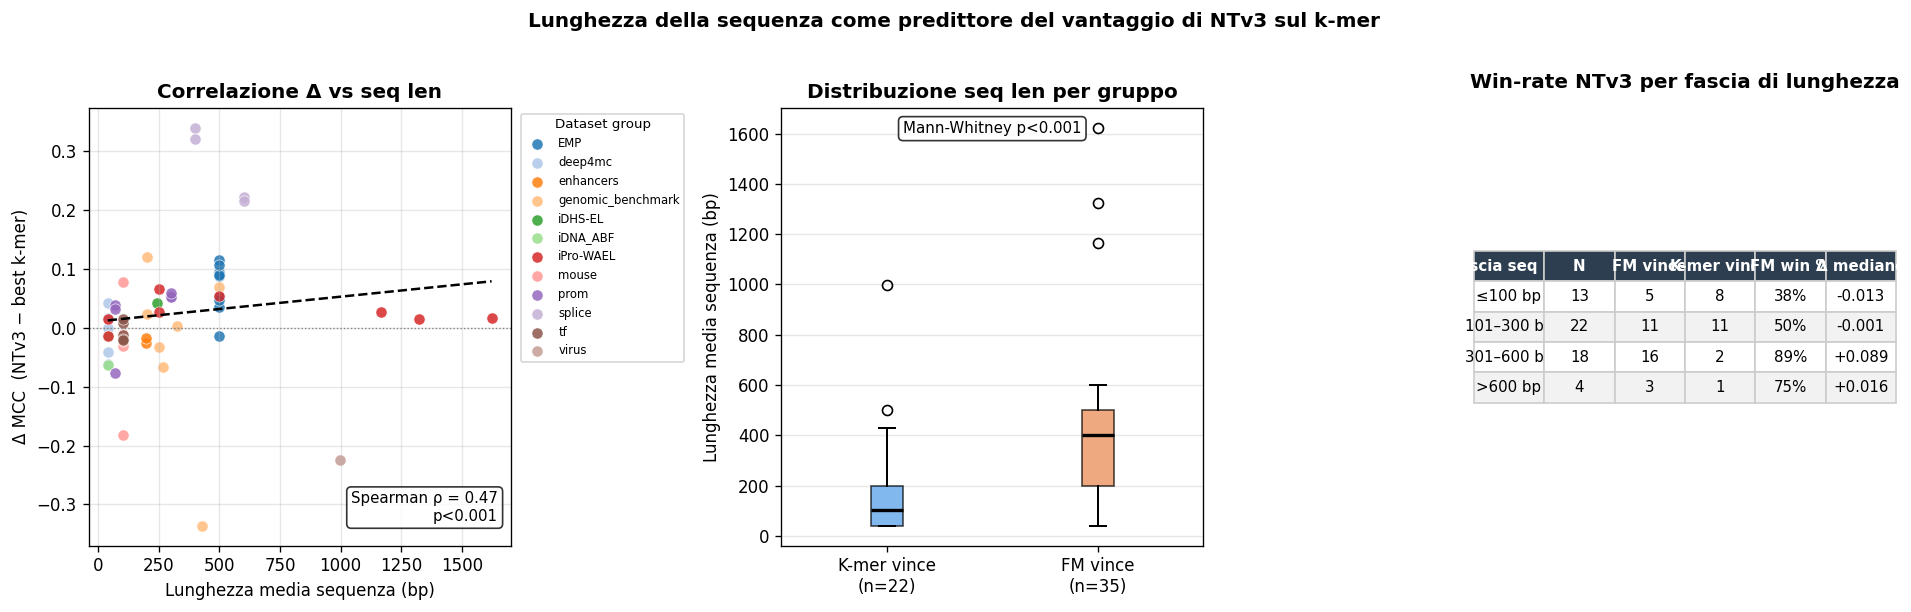

In [14]:
ntv3_mcc  = pd.to_numeric(df['fm_NTv3_650M_pre_MCC'], errors='coerce')
delta     = (ntv3_mcc - best_kmer(df)).rename('delta')
seq_len   = pd.to_numeric(df['seq_len_mean'], errors='coerce')

base = pd.DataFrame({'delta': delta, 'seq_len': seq_len, 'group': df['group']}).dropna()
fm_wins   = base[base['delta'] >  0]['seq_len']
kmer_wins = base[base['delta'] <= 0]['seq_len']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Pannello 1: scatter Δ vs seq_len ─────────────────────────────────────────
ax = axes[0]
for g, sub in base.groupby('group'):
    ax.scatter(sub['seq_len'], sub['delta'],
               label=g, alpha=0.85, s=45, color=palette[g],
               edgecolors='white', lw=0.4)

# Linea di regressione
m, b_int, r, p, _ = stats.linregress(base['seq_len'], base['delta'])
rho, pval = stats.spearmanr(base['seq_len'], base['delta'])
xl = np.array([base['seq_len'].min(), base['seq_len'].max()])
ax.plot(xl, m * xl + b_int, color='black', lw=1.5, ls='--', zorder=5)
ax.axhline(0, color='gray', lw=0.8, ls=':')

pstr = '<0.001' if pval < 0.001 else f'={pval:.3f}'
ax.text(0.97, 0.05,
        f'Spearman ρ = {rho:.2f}\np{pstr}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax.set_xlabel('Lunghezza media sequenza (bp)', fontsize=10)
ax.set_ylabel('Δ MCC  (NTv3 − best k-mer)', fontsize=10)
ax.set_title('Correlazione Δ vs seq len', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left',
          title='Dataset group', fontsize=7, title_fontsize=8)

# ── Pannello 2: boxplot seq_len nei due gruppi ───────────────────────────────
ax = axes[1]
data_box  = [kmer_wins.values, fm_wins.values]
labels_box = [f'K-mer vince\n(n={len(kmer_wins)})', f'FM vince\n(n={len(fm_wins)})']
bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
                medianprops=dict(color='black', lw=2),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
colors_box = ['#4C9BE8', '#E8854C']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

_, pval_mw = stats.mannwhitneyu(fm_wins, kmer_wins, alternative='two-sided')
pstr2 = '<0.001' if pval_mw < 0.001 else f'={pval_mw:.3f}'
ax.text(0.5, 0.97, f'Mann-Whitney p{pstr2}',
        transform=ax.transAxes, ha='center', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax.set_ylabel('Lunghezza media sequenza (bp)', fontsize=10)
ax.set_title('Distribuzione seq len per gruppo', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# ── Pannello 3: tabella win-rate per fascia di lunghezza ─────────────────────
ax = axes[2]
ax.axis('off')

bins   = [0, 100, 300, 600, np.inf]
labels = ['≤100 bp', '101–300 bp', '301–600 bp', '>600 bp']
base['fascia'] = pd.cut(base['seq_len'], bins=bins, labels=labels)

tbl_data = []
for fascia in labels:
    sub = base[base['fascia'] == fascia]
    if len(sub) == 0:
        continue
    fw = (sub['delta'] > 0).sum()
    tbl_data.append([fascia, len(sub), fw, len(sub) - fw,
                     f'{fw/len(sub)*100:.0f}%',
                     f'{sub["delta"].median():+.3f}'])

col_headers = ['Fascia seq len', 'N', 'FM vince', 'K-mer vince', 'FM win %', 'Δ mediano']
table = ax.table(cellText=tbl_data, colLabels=col_headers,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Colora header e righe per fascia
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F2F2F2')
    cell.set_edgecolor('#CCCCCC')

ax.set_title('Win-rate NTv3 per fascia di lunghezza', fontweight='bold', pad=12)

plt.suptitle('Lunghezza della sequenza come predittore del vantaggio di NTv3 sul k-mer',
             y=1.01, fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Beneficio della concatenazione FM + k-mer
Asse x: il migliore dei due approcci singoli (max tra best FM e best k-mer).  
Asse y: MCC del vettore concatenato FM + k-mer.  
**Sopra la diagonale** → la concatenazione ha migliorato le prestazioni.

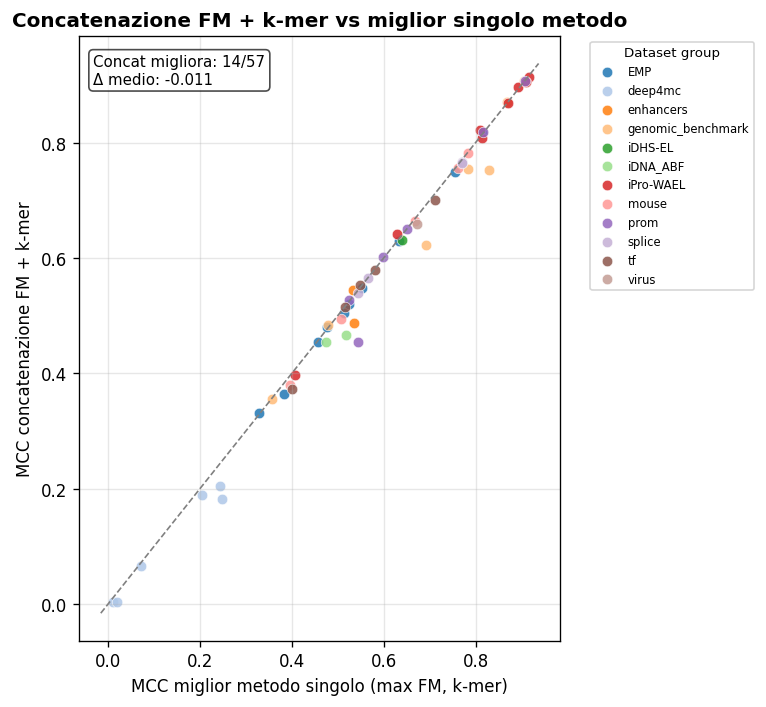

In [15]:
# Miglior singolo metodo per dataset
best_individual = pd.concat([best_kmer(df), best_fm(df)], axis=1).max(axis=1)
best_individual.name = 'best_individual_MCC'

# Concat MCC
concat_mcc = pd.to_numeric(df_concat['MCC'], errors='coerce')

# Join sui dataset comuni
merged = pd.concat([best_individual, concat_mcc], axis=1).dropna()
merged.columns = ['best_individual', 'concat']
merged['group'] = df.loc[merged.index, 'group']

fig, ax = plt.subplots(figsize=(6.5, 6))

for g, sub in merged.groupby('group'):
    ax.scatter(sub['best_individual'], sub['concat'],
               label=g, alpha=0.85, s=40, color=palette[g],
               edgecolors='white', lw=0.4)

lo = merged[['best_individual', 'concat']].values.min() - 0.02
hi = merged[['best_individual', 'concat']].values.max() + 0.02
ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1)

concat_wins = (merged['concat'] > merged['best_individual']).sum()
n = len(merged)
ax.text(0.03, 0.97,
        f'Concat migliora: {concat_wins}/{n}\n'
        f'Δ medio: {(merged["concat"] - merged["best_individual"]).mean():+.3f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

ax.set_xlabel('MCC miglior metodo singolo (max FM, k-mer)', fontsize=10)
ax.set_ylabel('MCC concatenazione FM + k-mer', fontsize=10)
ax.set_title('Concatenazione FM + k-mer vs miglior singolo metodo', fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          title='Dataset group', fontsize=7, title_fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()